# Lab 4: Object Oriented Programming Part II

Welcome to Lab 4 of Programming Methods! In this class we continue exploring Object Oriented Programming (OOP) by building a data transformation pipeline with composition. An optional stretch exercise explores Thomas Schelling's model of segregation. The lab has **one** main exercise, **one** optional stretch exercise and **four** wrap-up questions at the end.

Create a new branch for this Lab (e.g., `git checkout -b lab-04-oop2`).

Then, complete the following exercises in **this** Jupyter Notebook.

Once you are done **commit your work** using the proper Git commands.

Good luck :)

### Pipelines, composition, and agent-based simulation

Last time we used inheritance. This time we will build small reusable pieces and combine them into a pipeline.

The goal is to practice **composition**: an object contains other objects and coordinates their behavior.

By the end of this notebook you should have:

- a base class (**PipelineStage**) with a shared `transform()` interface
- a few concrete stage classes that implement that interface
- a **Pipeline** class that stores stages and runs them in order


## A quick note before you start...

Last class used inheritance. This class uses **composition**: an object contains other objects and calls their methods instead of inheriting their behavior.

This is useful when you want small, focused pieces that can be rearranged or replaced without changing the whole design.

The optional stretch exercise introduces a simple agent-based simulation using the same idea: a grid object and a simulation object working together.

### By the end of this class, you should be able to:

- explain the difference between inheritance and composition
- create a `PipelineStage` interface with a shared `transform()` method
- build a `Pipeline` that holds and runs multiple stages

## Setup

Run this cell first.

In [127]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Optional
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pm_labs.api_clients import APIClient

## Exercise 1: Data Transformation Pipeline

A real data pipeline is usually made of several small steps:
- fetch data
- clean it
- rename columns
- add derived values
- drop bad rows

Each step should be easy to test and easy to reorder.

In this exercise we fetch Wikipedia pageviews, transform them with a series of stages, and then compose those stages into a single pipeline.

> ⚠️ **Wikimedia requires a real `User-Agent` header.** Without it, the request may fail with a `403`.

In [128]:
class WikipediaClient(APIClient):
    def __init__(self):
        super().__init__(
            base_url="https://wikimedia.org/api/rest_v1"
        )
        self.headers = {
            "User-Agent": "Programming Methods Course (your-email@example.com)"
        }

    def get_pageviews(
        self,
        article: str,
        start: str,
        end: str,
    ) -> list[dict]:
        endpoint = (
            f"/metrics/pageviews/per-article/"
            f"en.wikipedia/all-access/user/"
            f"{article}/monthly/{start}/{end}"
        )

        raw = self._request(
            "GET",
            endpoint,
            headers=self.headers,
        )

        return raw["items"]

In [129]:
# Fetch Wikipedia pageviews for the Python programming language from 2023-01-01 to 2026-01-01
# 
raw_data = WikipediaClient().get_pageviews(
    article="Python programming language",
    start="20230101",
    end="20260101"
)

### 1a. Define the base class **PipelineStage**

Every stage should expose the same interface: a `.transform(df)` method that
takes a DataFrame and returns a new (or modified) DataFrame. That shared
interface is what will let `Pipeline` treat every stage identically,
regardless of what it actually does internally.

1. Create the base class **PipelineStage** with the `.transform(df)` method.
2. Have the base method raise `NotImplementedError` so subclasses must supply their own behavior.

In [130]:
class PipelineStage:
    """Base class for a single step in a data transformation pipeline."""

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError

### 1b. Implement the concrete stages

Implement the following four subclasses of **PipelineStage**. Each `__init__`
should accept whatever parameters it needs, so the same stage class can be
reused with different settings.

1. **DropMissingStage**: drops rows where any of a given list of columns is null.
   - `__init__(self, columns: list[str])`
2. **RenameColumnsStage**: renames columns according to a mapping.
   - `__init__(self, mapping: dict[str, str])`
3. **ParseTimestampStage**: converts a Wikimedia timestamp (format `%Y%m%d%H`) to a monthly period string (`%Y-%m`) in a new column.
   - `__init__(self, timestamp_col: str, new_col: str = "period")`
4. **AddGrowthRateStage**: adds the change from the preceding observation as a fraction, computed *within each article*. Sort by both the group and date columns before computing it.
   - `__init__(self, group_col: str, value_col: str, date_col: str, new_col: str = "growth_rate")`

In [138]:
class DropMissingStage(PipelineStage):
    def __init__(self, columns: list[str]):
        self.columns = columns

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return df.dropna(subset=self.columns).reset_index(drop=True)

In [139]:
class RenameColumnsStage(PipelineStage):
    def __init__(self, mapping: dict[str, str]):
        self.mapping = mapping

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df.rename(columns=self.mapping) # {"old_col_name": "new_col_name"}

In [147]:
class ParseTimestampStage(PipelineStage):
    def __init__(self, timestamp_col: str, new_col: str = "period"):
        self.timestamp_col = timestamp_col
        self.new_col = new_col

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df[self.new_col] = pd.to_datetime(
            df[self.timestamp_col], format="%Y%m%d%H"
        ).dt.strftime("%Y-%m")
        return df

In [148]:
raw_df = pd.DataFrame(raw_data)
raw_df

,project,article,granularity,timestamp,access,agent,views
0,en.wikipedia,Python_programming_language,monthly,2023010100,all-access,user,577
1,en.wikipedia,Python_programming_language,monthly,2023020100,all-access,user,491
2,en.wikipedia,Python_programming_language,monthly,2023030100,all-access,user,1003
3,en.wikipedia,Python_programming_language,monthly,2023040100,all-access,user,897
4,en.wikipedia,Python_programming_language,monthly,2023050100,all-access,user,466
5,en.wikipedia,Python_programming_language,monthly,2023060100,all-access,user,599
6,en.wikipedia,Python_programming_language,monthly,2023070100,all-access,user,521
7,en.wikipedia,Python_programming_language,monthly,2023080100,all-access,user,488
8,en.wikipedia,Python_programming_language,monthly,2023090100,all-access,user,402
9,en.wikipedia,Python_programming_language,monthly,2023100100,all-access,user,380


In [149]:
class AddGrowthRateStage(PipelineStage):
    def __init__(
        self,
        group_col: str,
        value_col: str,
        date_col: str,
        new_col: str = "growth_rate",
    ):
        self.group_col = group_col
        self.value_col = value_col
        self.date_col = date_col
        self.new_col = new_col


    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df.sort_values()([self.group_col, self.date_col]).reset_index(drop = True)
        df[self.new_col] = df.groupby(self.group_col)[self.value_col].pct_change()
        return df

### 1c. Define the Pipeline class (composition)

Create a `Pipeline` class that stores stage objects and runs them in order.

- it should not inherit from `PipelineStage`
- it should have an `add_stage()` method
- it should have a `run()` method that applies each stage to the DataFrame

This is composition: the pipeline contains stages instead of being a stage itself.


In [150]:
class Pipeline:
    def __init__(self, stages: Optional[list[PipelineStage]] = None):
        self.stages = stages or []

    def add_stage(self, stage: PipelineStage) -> "Pipeline":
        # TODO: append the stage and return the pipeline.
        self.stages.append(stage)
        return self

    def run(self, df: pd.DataFrame) -> pd.DataFrame:
        # TODO: apply each stage in order and return the final DataFrame.
        for stage in self.stages:
            df = stage.transform(df)

        return df


### 1d. Put it together

Build a pipeline with the stages below and run it on `raw_df`.

1. rename the relevant columns
2. parse the timestamp
3. add a growth-rate column
4. drop rows with missing growth values

Then try reordering the stages and ask whether the output changes.


In [151]:
pipeline = Pipeline()
# TODO: add stages to rename the timestamp, parse it, calculate growth, and drop missing growth values.
# TODO: run the pipeline on raw_df and inspect the result.

 
pipeline.add_stage(DropMissingStage(["views"])) \
        .add_stage(RenameColumnsStage({"timestamp":"raw_timestamp"})) \
        .add_stage(ParseTimestampStage(timestamp_col="raw_timestamp", new_col="period")) \
        .add_stage(AddGrowthRateStage(group_col="article", date_col="period", value_col="views")) \
        .add_stage(DropMissingStage(["growth_rate"]))
 
result = pipeline.run(raw_df)
 
 

AttributeError: 'NoneType' object has no attribute 'copy'

**Your answer:** How does changing the order of the stages affect the result? Which stages depend on columns or values created by earlier ones?

### 💡 A closer look: what happens at a gap?

Wikipedia does not always return every month. If a month is missing, the data just
skips that date instead of storing a `0` or `NaN`.

This matters because `pct_change()` compares each row to the previous row in the
DataFrame. If a month is missing, the next value is compared to the last available month,
not to the month that should have been there.

**Quick question:**
1. Does a missing month still produce a valid `growth_rate` value?
2. Is that value really "month-over-month" growth?
3. Would `DropMissingStage(["growth_rate"])` catch the problem?


**Your answer:** Check whether any months are missing from the fetched data. What does that mean for the growth rate after a gap, and would dropping missing growth values detect it?

> #### 📚 Further reading
> - Nelson, *Software Engineering for Data Scientists*, **Chapter 8 "Design and Refactoring"** — sections "Modular Code," "Interfaces and Contracts," and "Coupling" describe the design goal of this exercise: small, interchangeable units connected through a shared interface, so that changing one stage doesn't ripple into the others.
> - Ramalho, *Fluent Python* (2nd ed.), **Chapter 13 "Interfaces, Protocols, and ABCs"** — covers how to formally define and enforce an interface like `PipelineStage.transform()` using `abc.ABC` and `@abstractmethod`, instead of relying on `NotImplementedError` as a convention.

---
## Optional Stretch: Schelling's Model of Segregation

Thomas Schelling's 1971 model shows how even a *mild* individual preference
for having neighbors similar to yourself can produce highly segregated
neighborhoods at the population level - a classic result in agent-based
modeling.

**The rules:**
- Agents live on a 2D grid; each cell is empty or holds one agent belonging
  to one of two groups.
- An agent is **happy** if at least some fraction (the *similarity
  threshold*, e.g. 30%) of its occupied neighboring cells belong to its own
  group.
- On each simulation step, every **unhappy** agent moves to a random empty
  cell.
- Repeat until (almost) everyone is happy, or for a fixed number of steps.

We'll build this with three classes: **Agent**, **SegregationGrid**, and
**SchellingSimulation**.

### Create the **Agent** class

This class should be small and focused: an agent just needs to know which group
it belongs to.  It should also have a readable `__repr__`, as it will be useful when
debugging the grid later.


In [ ]:
class Agent:
    def __init__(self, group: int):
        # TODO: store the agent's group.
        pass

    def __repr__(self) -> str:
        # TODO: return a readable representation of the agent.
        pass

### b. Create the **SegregationGrid** class

This class owns the 2D grid and everything about its geometry. Store the
grid as a 2D NumPy array of *object* dtype, where each cell holds either an
`Agent` instance or `None` (empty).

Implement the **class constructor** and **three functions**:
1. `__init__(self, size, empty_ratio, group_ratio, seed=None)`: randomly
  populates a *size x size* grid. *empty_ratio* fraction of cells are `None`,
  the rest hold `Agent` objects split between group 0 and group 1 according
  to *group_ratio*.

2. `neighbors(self, row, col)`: returns the (up to 8) neighboring *(row, col)*
  coordinates that are inside the grid (careful with edges and corners).
3. `empty_cells(self)`: returns a list of *(row, col)* coordinates that are
  currently `None`.
4. `is_happy(self, row, col, threshold)`: given an agent at *(row, col)*,
  looks at its occupied neighbors and returns `True` if the fraction
  belonging to the same group is *>= threshold*. An agent with **no occupied
  neighbors** should count as happy (nothing to be unhappy about).


In [ ]:
class SegregationGrid:
    def __init__(self, size: int, empty_ratio: float, group_ratio: float, seed: Optional[int] = None):
        # TODO: create and randomly populate an object-dtype grid with agents and empty cells.
        pass

    def neighbors(self, row: int, col: int) -> list[tuple[int, int]]:
        # TODO: return valid neighboring coordinates (including diagonals).
        pass

    def empty_cells(self) -> list[tuple[int, int]]:
        # TODO: find the coordinates of all empty cells.
        pass

    def is_happy(self, row: int, col: int, threshold: float) -> bool:
        # TODO: compare the agent's group with its occupied neighbors.
        pass

### c. Create the **SchellingSimulation** class

This class *composes* a `SegregationGrid` (composition again) 
and drives the simulation forward.

Implement the **class constructor** and **two functions**:
1. `__init__(self, grid: SegregationGrid, threshold: float)`

2. `step(self)`: finds every unhappy agent, and for each one (in random
  order), moves it to a randomly chosen empty cell. Returns the number of
  agents that moved.
3. `run(self, max_steps: int)`: calls `step()` repeatedly, stopping early if
  a step results in zero moves (the system has stabilized). Should track and
  return the number of moves per step as a list, so you can plot how
  quickly the system settles.


In [ ]:
class SchellingSimulation:
    def __init__(self, grid: SegregationGrid, threshold: float):
        # TODO: store the grid and similarity threshold.
        pass

    def step(self) -> int:
        # TODO: move unhappy agents to randomly selected empty cells; return the move count.
        pass

    def run(self, max_steps: int) -> list[int]:
        # TODO: repeat steps until no one moves or the limit is reached; return moves per step.
        pass

### Visualize

The provided `plot_grid(grid, ax=None)` function renders a *SegregationGrid*
as a colored image: one color for group 0, another for group 1, and a third
for empty cells. Once your classes work, run the next cell to compare the
grid before and after the simulation.

AttributeError: 'SegregationGrid' object has no attribute 'size'

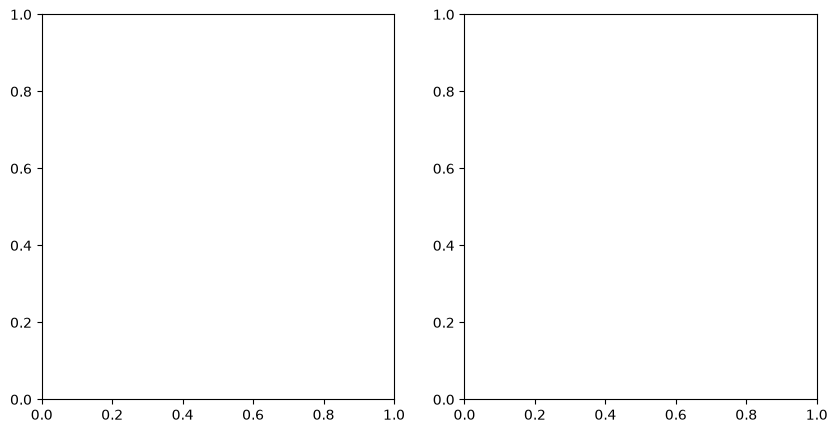

In [ ]:
def plot_grid(grid: "SegregationGrid", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    display = np.full((grid.size, grid.size), -1, dtype=int)
    for r in range(grid.size):
        for c in range(grid.size):
            agent = grid.grid[r, c]
            if agent is not None:
                display[r, c] = agent.group

    ax.imshow(display, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


schelling_grid = SegregationGrid(size=20, empty_ratio=0.1, group_ratio=0.5, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_grid(schelling_grid, ax=axes[0])
axes[0].set_title("Before")

sim = SchellingSimulation(schelling_grid, threshold=0.4)
moves_per_step = sim.run(max_steps=50)

plot_grid(schelling_grid, ax=axes[1])
axes[1].set_title(f"After ({len(moves_per_step)} steps)")
plt.show()


The plot above shows the grid as a colored image: **blue** cells are empty,
**light/white** cells are Group 0 agents, and **red** cells are Group 1 agents.
Compare the "Before" and "After" grids. Do you see clusters forming?

### Experiment

The final plot has the `moves_per_step` (moves on the y-axis, step number on the x-axis) 
that allows to see how quickly the system stabilizes. Running the simulation with
a few different `threshold` values (try `0.2`, `0.5`, `0.8`) allows for comparing the
resulting grids.

**Question to answer in a markdown cell below:** Schelling's famous finding
was that even a *mild* preference for similar neighbors (a low threshold,
well under 50%) is enough to produce strong segregation. Does your
simulation show that? What threshold seems to be the tipping point in your
runs?


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(moves_per_step)
plt.xlabel("Step")
plt.ylabel("Agents moved")
plt.title("Convergence of the simulation")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, threshold in zip(axes, [0.2, 0.5, 0.8]):
    g = SegregationGrid(size=20, empty_ratio=0.1, group_ratio=0.5, seed=42)
    s = SchellingSimulation(g, threshold=threshold)
    s.run(max_steps=100)
    plot_grid(g, ax=ax)
    ax.set_title(f"threshold={threshold}")
plt.show()

**Your answer:** Describe what you observe at each threshold. Does a low threshold produce visible clusters? What threshold appears to change the outcome most in your runs?

> #### 📚 Further reading
> - Nelson, *Software Engineering for Data Scientists*, **Chapter 4 "Object-Oriented Programming and Functional Programming"** — the classes-and-attributes fundamentals you're now applying to a stateful, evolving system rather than a request/response client.
> - Nelson, **Chapter 3 "Using Data Structures Effectively"** — the section on NumPy arrays and array operations is directly relevant to representing and updating the grid efficiently.
> - Ramalho, *Fluent Python* (2nd ed.), **Chapter 6 "Object References, Mutability, and Recycling"** — `SchellingSimulation.step()` mutates the same `Agent` objects and the same grid array in place as agents move. This chapter explains exactly what's happening under the hood when you reassign `self.grid.grid[row][col]` versus creating a new object, and why that distinction matters for a simulation with moving, identity-bearing agents.
> - Ramalho, **Chapter 11 "A Pythonic Object"** — covers writing a good `__repr__` (and `__eq__`, if you want agents to be comparable), which is what makes `Agent` pleasant to work with in Exercise 2a.


## Wrap-up questions (answer briefly in markdown)

### 1. Why might we prefer composition over making `Pipeline` inherit from `PipelineStage`?

A) Because a `Pipeline` cannot implement a `transform()` method.  
B) Because inheritance would prevent a pipeline from containing multiple stages.  
C) Because a `Pipeline` conceptually orchestrates/contains stages rather than simply being a type of transformation stage.  
D) Because composition is always preferable to inheritance in object-oriented programming.

**Your answer:**

---

### 2. Why does `SchellingSimulation` contain a `SegregationGrid` instead of putting all simulation logic inside `SegregationGrid`?

A) To separate the representation and behavior of the grid from the logic controlling how the simulation evolves.  
B) Because `SegregationGrid` cannot contain methods such as `step()` or `run()`.  
C) Because Python does not allow one class to manage both data and behavior.  
D) To make `SchellingSimulation` responsible for storing the agents instead of the grid.

**Your answer:**

---

### 3. What does the fact that reordering pipeline stages can change the result tell us?

A) Pipeline stages should always be executed alphabetically.  
B) A common `transform(df) -> df` interface is enough to guarantee that stages can be executed in any order.  
C) Each stage should document not only its interface, but also what it expects from its input and guarantees about its output.  
D) Pipeline stages should never modify a DataFrame.

**Your answer:**

---

### 4. Suppose we extend the Schelling model from two groups to three groups. Which part of the current design necessarily needs to change?

A) `Agent`, because its `group` attribute only supports two groups.  
B) `is_happy()`, because it explicitly compares group 0 with group 1.  
C) `SchellingSimulation`, because its `step()` method only works with two groups.  
D) The grid initialization logic, because it explicitly creates agents belonging to two groups.

**Your answer:**